In [ ]:

%pip install yfinance

  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-3.18.3-py3-none-any.whl
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.14.0-cp39-abi3-win_amd64.whl.metadata (15 kB)
  Using cached websockets-15.0.1-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
  Using cached soupsieve-2.8-py3-none-any.whl.metadata (4.6 kB)
  Using cached cffi-2.0.0-cp311-cp311-win_amd64.whl.metadata (2.6 kB)
  Using cached pycparser-2.23-py


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kriti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB 217.9 kB/s eta 0:00:44
   - -------------------------------------- 0.2/9.6 MB 2.2 MB/s eta 0:00:05
   ---- ----------------------------------- 1.2/9.6 MB 7.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.3/9.6 MB 10.4 MB/s eta 0:00:01
   ------------- -------------------------- 3.3/9.6 MB 12.6 MB/s eta 0:00:01
   ----------------- ---------------------- 4.1/9.6 MB 13.2 MB/s eta 0:00:01
   ---------------------- ----------------- 5.4/9.6 MB 15.8 MB/s eta 0:00:01
   ---------------------------- ----------- 6.9/9.6 MB 17.7 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 19.3 MB/s eta 0:00:01
   -------------------------------------- - 9.1/9.6 MB 18.8 MB/s eta 0:00:01
   ---------------------------------------  9.6/9.6 MB 19.1 MB/s eta 0:00:01
   -------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kriti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
%pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 458.0 kB/s eta 0:00:00
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     -------------------------------------- 116.4/116.4 kB 3.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.2/8.1 MB 37.0 MB/s eta 0:00:01
   ----------------- ---------------------- 3.6/8.1 MB 46.6 MB/s eta 0:00:01
   --------------------- ------------------ 4.3/8.1 MB 34.6 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 32.2 MB/s eta 0:00:01
   ----------------------------- ---------- 5.9/8.1 MB 29.1 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 27.1 MB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\kriti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# LIBRARIES
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [5]:
# DOWNLOAD DATA FROM YAHOO FINANCE
tickers = ['AAPL', 'MSFT', 'GOOGL']
weights = np.array([0.4, 0.35, 0.25])  # The weights must sum to 1
prices = yf.download(tickers, start='2022-01-01', end='2025-11-30', interval='1d', auto_adjust=True, progress=False)['Close']
print(prices.columns)
prices.dropna(inplace=True)
print(prices.head())

prices.to_csv('stock_prices_2025.csv')

Index(['AAPL', 'GOOGL', 'MSFT'], dtype='object', name='Ticker')
Ticker            AAPL       GOOGL        MSFT
Date                                          
2022-01-03  178.270309  143.904190  323.898376
2022-01-04  176.007767  143.316650  318.344513
2022-01-05  171.325989  136.741806  306.123871
2022-01-06  168.466003  136.714508  303.704987
2022-01-07  168.632507  135.989517  303.859741


In [15]:
# RETURN CALCULATION FUNCTION
def log_returns(prices):
    return np.log(prices / prices.shift(1)).dropna()

returns = log_returns(prices) # assets' returns DataFrame
weights = pd.Series(weights, index=returns.columns)  # Align weights with asset names

# Safety checks
assert np.isclose(weights.sum(), 1), "Weights must sum to 1"
assert set(weights.index) == set(returns.columns), "Weights and assets mismatch"

portfolio_returns = returns.mul(weights).sum(axis=1)
print(portfolio_returns)

Date
2022-01-04   -0.010865
2022-01-05   -0.037007
2022-01-06   -0.008787
2022-01-07   -0.001338
2022-01-10    0.004425
                ...   
2025-11-21    0.016610
2025-11-24    0.028897
2025-11-25    0.008390
2025-11-26    0.001461
2025-11-28    0.005451
Length: 980, dtype: float64


In [16]:
# ROLLING PARAMETRIC VaR CALCULATION
from scipy.stats import norm

window = 250         # 1-year rolling window
confidence = 0.99
z = norm.ppf(confidence)

rolling_var = []

for i in range(window, len(portfolio_returns)):
    hist_returns = portfolio_returns.iloc[i-window:i]
    mu = hist_returns.mean()
    sigma = hist_returns.std()
    var_t = z * sigma - mu
    rolling_var.append(var_t)

rolling_var = pd.Series(
    rolling_var,
    index=portfolio_returns.index[window:]
)
test_returns = portfolio_returns.loc[rolling_var.index]

print("Total return observations:", len(portfolio_returns))
print("Rolling window size:", window)

Total return observations: 980
Rolling window size: 250


In [18]:
# BACKTESTING
exceptions = test_returns < -rolling_var
num_exceptions = exceptions.sum()

accuracy_pct = (1 - num_exceptions / len(test_returns)) * 100
exception_rate = num_exceptions / len(test_returns)

print("Backtesting Results")
print("-------------------")
print(f"Number of Observations: {len(test_returns)}")
print(f"Number of Exceptions: {num_exceptions}")
print(f"VaR Model Accuracy: {accuracy_pct:.2f}%")
print(f"Exception Rate: {exception_rate:.2%}")

Backtesting Results
-------------------
Number of Observations: 730
Number of Exceptions: 12
VaR Model Accuracy: 98.36%
Exception Rate: 1.64%


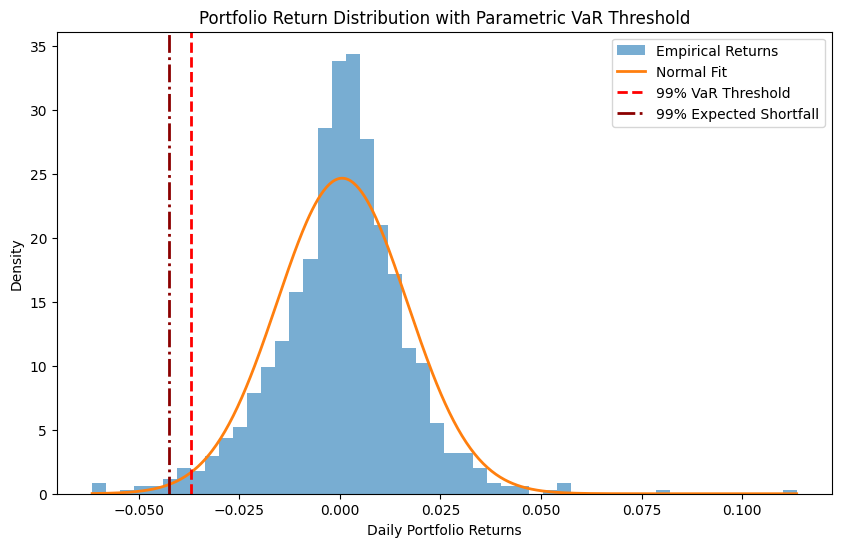

In [19]:
# PLOTTING
# 1. Plot portfolio return distribution and VaR threshold

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z_score = norm.ppf(1-confidence)

# 99% left-tail VaR (loss is positive)
var_static = -(mu + sigma * z_score)

es_static = -mu + sigma * (norm.pdf(z_score) / (1 - confidence))

plt.figure(figsize=(10, 6))

# Histogram of portfolio returns
plt.hist(
    portfolio_returns,
    bins=50,
    density=True,
    alpha=0.6,
    label="Empirical Returns"
)

# Normal distribution fit
x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 500)
pdf = norm.pdf(x, mu, sigma)
plt.plot(x, pdf, linewidth=2, label="Normal Fit")

# VaR threshold (left tail)
plt.axvline(
    -var_static,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"{int(confidence*100)}% VaR Threshold"
)

# Expected Shortfall line
plt.axvline(
    -es_static,
    color="darkred",
    linestyle="-.",
    linewidth=2,
    label=f"{int(confidence*100)}% Expected Shortfall"
)

plt.title("Portfolio Return Distribution with Parametric VaR Threshold")
plt.xlabel("Daily Portfolio Returns")
plt.ylabel("Density")
plt.legend()
plt.show()

<Figure size 600x600 with 0 Axes>

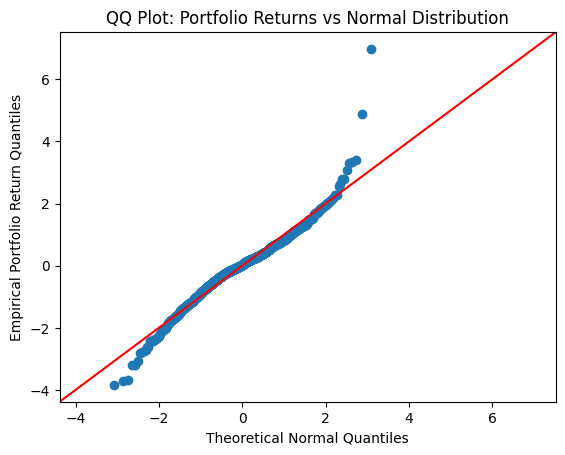

In [20]:
# 2. Q-Q Plot

plt.figure(figsize=(6, 6))

# Standardize returns for fair comparison
standardized_returns = (
    portfolio_returns - portfolio_returns.mean()
) / portfolio_returns.std()

# QQ plot
sm.qqplot(
    standardized_returns,
    line="45",
    fit=False
)

plt.title("QQ Plot: Portfolio Returns vs Normal Distribution")
plt.xlabel("Theoretical Normal Quantiles")
plt.ylabel("Empirical Portfolio Return Quantiles")
plt.show()